# Projeto: Detecção de Domínios Funcionais em Proteínas
**Disciplina:** Redes Complexas  
**Alvo principal:** 6B1T (Adenovírus Humano 5)  
**Linguagem:** Python  

---

## Pipeline
1. Obtenção e preparação dos dados (PDB)
2. Leitura e parsing do arquivo PDB
3. Construção da rede de contatos entre resíduos
4. Análise topológica (graus, centralidades)
5. Detecção de comunidades (Louvain)
6. Validação biológica
7. Estratégia de teste (proteína pequena antes do alvo)

> **Declaração de uso de IA:** Código auxiliado por Claude Sonnet 4.6 (Anthropic). Temperatura padrão.

## 0. Instalação de dependências

In [1]:
# Instalar dependências necessárias
import subprocess, sys

packages = [
    "biopython",        # parsing de PDB
    "networkx",         # construção e análise de grafos
    "python-louvain",   # detecção de comunidades (Louvain)
    "matplotlib",       # visualizações
    "numpy",
    "scipy",
    "pandas",
    "seaborn",
    "requests",         # download de arquivos PDB
    "tqdm",             # barras de progresso
    "py3Dmol",          # visualização 3D inline (opcional)
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Todas as dependências instaladas com sucesso!")

Todas as dependências instaladas com sucesso!


## 1. Importações e configurações globais

In [2]:
import os
import gzip
import tarfile
import requests
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from itertools import combinations
from tqdm import tqdm
from scipy.spatial.distance import cdist

# BioPython
from Bio import PDB
from Bio.PDB import PDBParser, MMCIFParser
from Bio.PDB.Polypeptide import is_aa

# Louvain
import community as community_louvain  # python-louvain

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Diretório de trabalho
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

print("Importações concluídas.")

Importações concluídas.


## 2. Funções utilitárias: download e parsing de PDB

In [3]:
# ─────────────────────────────────────────────────────────────
#  DOWNLOAD
# ─────────────────────────────────────────────────────────────

def download_pdb(pdb_id: str, dest_dir: Path = DATA_DIR) -> Path:
    """
    Tenta baixar via RCSB REST API (formato CIF comprimido).
    Retorna o caminho local do arquivo .cif.gz ou .pdb.gz.
    """
    pdb_id = pdb_id.upper()
    out_path_cif = dest_dir / f"{pdb_id}.cif.gz"
    out_path_pdb = dest_dir / f"{pdb_id}.pdb.gz"

    if out_path_cif.exists():
        print(f"[cache] {pdb_id}.cif.gz já existe.")
        return out_path_cif
    if out_path_pdb.exists():
        print(f"[cache] {pdb_id}.pdb.gz já existe.")
        return out_path_pdb

    # Tenta CIF primeiro (mais completo)
    urls = [
        (f"https://files.rcsb.org/download/{pdb_id}.cif.gz", out_path_cif),
        (f"https://files.rcsb.org/download/{pdb_id}.pdb.gz", out_path_pdb),
    ]
    for url, path in urls:
        r = requests.get(url, stream=True, timeout=120)
        if r.status_code == 200:
            with open(path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Download concluído: {path}")
            return path

    raise FileNotFoundError(f"Não foi possível baixar {pdb_id} do RCSB.")


def parse_structure(file_path: Path):
    """
    Lê estrutura PDB ou CIF (comprimida ou não).
    Retorna objeto Bio.PDB.Structure.
    """
    name = file_path.stem.replace(".cif", "").replace(".pdb", "").upper()
    suffix = "".join(file_path.suffixes).lower()

    def _open(path):
        if str(path).endswith(".gz"):
            return gzip.open(path, "rt")
        return open(path, "r")

    if ".cif" in suffix:
        parser = MMCIFParser(QUIET=True)
    else:
        parser = PDBParser(QUIET=True)

    with _open(file_path) as fh:
        structure = parser.get_structure(name, fh)

    print(f"Estrutura '{name}' carregada: "
          f"{len(list(structure.get_chains()))} cadeias, "
          f"{len(list(structure.get_residues()))} resíduos.")
    return structure


def get_residue_info(structure) -> pd.DataFrame:
    """
    Extrai DataFrame com um resíduo por linha:
    id_node, chain, resname, resseq, x, y, z (centroide do CA ou resíduo).
    """
    records = []
    for model in structure:
        for chain in model:
            for res in chain:
                if not is_aa(res, standard=True):
                    continue
                # Usa CA se existir, senão centroide de todos os átomos
                if "CA" in res:
                    coord = res["CA"].get_vector().get_array()
                else:
                    coords = np.array([a.get_vector().get_array() for a in res.get_atoms()])
                    coord = coords.mean(axis=0)
                records.append({
                    "node": f"{chain.id}_{res.get_id()[1]}",
                    "chain": chain.id,
                    "resname": res.get_resname(),
                    "resseq": res.get_id()[1],
                    "x": coord[0],
                    "y": coord[1],
                    "z": coord[2],
                })
        break  # Apenas o primeiro modelo (NMR pode ter vários)
    df = pd.DataFrame(records).drop_duplicates("node").set_index("node")
    print(f"Resíduos padrão (aminoácidos): {len(df)}")
    return df

print("Funções de I/O definidas.")

Funções de I/O definidas.


## 3. Construção da rede de contatos entre resíduos

**Modelagem escolhida — Protein Contact Network (PCN):**

- **Nós:** um por resíduo de aminoácido (posição = Cα)
- **Arestas:** ligação entre dois resíduos se a distância Cα–Cα ≤ `cutoff` Å
- **Pesos:** `w = 1 / d²` (resíduos mais próximos têm ligação mais forte)
- **Justificativa:** é a abordagem mais usada na literatura de redes de proteínas (Atilgan et al. 2004; Vishveshwara et al. 2009). O cutoff de 8 Å captura tanto contatos de cadeia principal quanto interações de cadeia lateral relevantes biologicamente, incluindo pontes H e contatos hidrofóbicos típicos. A ponderação por 1/d² reflete a intensidade decrescente da interação com a distância.

In [4]:
def build_contact_network(
    df_residues: pd.DataFrame,
    cutoff: float = 8.0,
    weight_fn=None,
    chunk_size: int = 2000,
) -> nx.Graph:
    """
    Constrói grafo não-dirigido ponderado de contatos.

    Parâmetros
    ----------
    df_residues : DataFrame com colunas x, y, z e index = node_id
    cutoff      : distância máxima em Angstrom para criar aresta
    weight_fn   : função(d) -> peso. Default: 1/d²
    chunk_size  : divide o cálculo em blocos para economizar memória
    """
    if weight_fn is None:
        weight_fn = lambda d: 1.0 / (d ** 2) if d > 0 else 0.0

    coords = df_residues[["x", "y", "z"]].values.astype(np.float32)
    nodes  = df_residues.index.tolist()
    n      = len(nodes)

    G = nx.Graph()
    G.add_nodes_from(
        [(nodes[i], {"chain": df_residues["chain"].iloc[i],
                     "resname": df_residues["resname"].iloc[i],
                     "resseq": int(df_residues["resseq"].iloc[i]),
                     "x": float(coords[i, 0]),
                     "y": float(coords[i, 1]),
                     "z": float(coords[i, 2])})
         for i in range(n)
        ]
    )

    edge_list = []
    for start in tqdm(range(0, n, chunk_size), desc="Calculando distâncias"):
        end_i = min(start + chunk_size, n)
        block = coords[start:end_i]              # (chunk, 3)
        dists = cdist(block, coords, "euclidean") # (chunk, n)

        rows, cols = np.where((dists > 0) & (dists <= cutoff))
        rows += start  # ajusta índice global

        for r, c in zip(rows, cols):
            if r < c:  # evita duplicatas
                w = weight_fn(dists[r - start, c])
                edge_list.append((nodes[r], nodes[c], w))

    G.add_weighted_edges_from(edge_list)
    print(f"Grafo construído: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")
    return G

print("Função de construção de rede definida.")

Função de construção de rede definida.


## 4. Análise topológica

In [5]:
def topological_analysis(G: nx.Graph, title: str = "") -> dict:
    """
    Calcula e plota:
    - Distribuição de graus
    - Centralidade de grau
    - Centralidade de intermediação (betweenness) — amostrado se > 5000 nós
    - Centralidade de proximidade (closeness)
    - PageRank
    """
    print(f"\n{'='*55}")
    print(f" Análise topológica: {title}")
    print(f"{'='*55}")

    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = dict(G.degree())
    deg_vals = np.array(list(degrees.values()))

    print(f"Nós: {n}  |  Arestas: {m}")
    print(f"Grau médio: {deg_vals.mean():.2f} ± {deg_vals.std():.2f}")
    print(f"Grau máximo: {deg_vals.max()}  |  Grau mínimo: {deg_vals.min()}")

    # ── Centralidades ──────────────────────────────────────────
    print("Calculando centralidade de grau...")
    dc = nx.degree_centrality(G)

    print("Calculando closeness centrality...")
    cc = nx.closeness_centrality(G)

    # Betweenness: amostrado para redes grandes
    if n > 5000:
        k_sample = min(500, n)
        print(f"Rede grande — betweenness amostrado (k={k_sample})...")
        bc = nx.betweenness_centrality(G, k=k_sample, normalized=True, weight="weight")
    else:
        print("Calculando betweenness centrality...")
        bc = nx.betweenness_centrality(G, normalized=True, weight="weight")

    print("Calculando PageRank...")
    pr = nx.pagerank(G, weight="weight")

    centralities = {"degree": dc, "closeness": cc, "betweenness": bc, "pagerank": pr}

    # Top-10 nós por betweenness
    top10 = sorted(bc.items(), key=lambda x: -x[1])[:10]
    print("\nTop-10 resíduos por Betweenness Centrality:")
    for node, val in top10:
        chain = G.nodes[node].get("chain", "?")
        res   = G.nodes[node].get("resname", "?")
        seq   = G.nodes[node].get("resseq", "?")
        print(f"  {node:15s}  chain={chain}  {res}{seq}  BC={val:.5f}")

    # ── Plots ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Análise Topológica — {title}", fontsize=13, fontweight="bold")

    # 1. Distribuição de graus (escala log-log)
    ax = axes[0]
    unique, counts = np.unique(deg_vals, return_counts=True)
    ax.loglog(unique, counts, "o", ms=4, alpha=0.7, color="steelblue")
    ax.set_xlabel("Grau (k)")
    ax.set_ylabel("Frequência P(k)")
    ax.set_title("Distribuição de graus (log-log)")
    ax.grid(True, alpha=0.3)

    # 2. Betweenness vs Degree
    ax = axes[1]
    bc_vals = np.array([bc[n_] for n_ in G.nodes()])
    ax.scatter(deg_vals, bc_vals, alpha=0.3, s=5, color="tomato")
    ax.set_xlabel("Grau")
    ax.set_ylabel("Betweenness Centrality")
    ax.set_title("Betweenness vs Grau")
    ax.grid(True, alpha=0.3)

    # 3. Distribuição de graus (histograma linear)
    ax = axes[2]
    ax.hist(deg_vals, bins=40, color="mediumseagreen", edgecolor="white", alpha=0.85)
    ax.axvline(deg_vals.mean(), color="red", linestyle="--", label=f"Média={deg_vals.mean():.1f}")
    ax.set_xlabel("Grau")
    ax.set_ylabel("Frequência")
    ax.set_title("Histograma de graus")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(DATA_DIR / f"topologia_{title.replace(' ','_')}.png", bbox_inches="tight")
    plt.show()

    return {"degrees": degrees, **centralities}

print("Função de análise topológica definida.")

Função de análise topológica definida.


## 5. Detecção de comunidades (Louvain)

In [6]:
def detect_communities_louvain(
    G: nx.Graph,
    resolution: float = 1.0,
    random_state: int = 42,
) -> dict:
    """
    Aplica o algoritmo de Louvain para detectar comunidades.
    Retorna dict {node: community_id} e imprime métricas.
    """
    print("Executando detecção de comunidades (Louvain)...")
    partition = community_louvain.best_partition(
        G, weight="weight", resolution=resolution, random_state=random_state
    )

    n_comm = len(set(partition.values()))
    modularity = community_louvain.modularity(partition, G, weight="weight")

    comm_sizes = defaultdict(int)
    for c in partition.values():
        comm_sizes[c] += 1

    sizes = sorted(comm_sizes.values(), reverse=True)

    print(f"\nComunidades detectadas : {n_comm}")
    print(f"Modularidade           : {modularity:.4f}")
    print(f"Maior comunidade       : {sizes[0]} nós")
    print(f"Menor comunidade       : {sizes[-1]} nós")
    print(f"Tamanho médio          : {np.mean(sizes):.1f} ± {np.std(sizes):.1f}")
    print("\nDistribuição de tamanhos:")
    for i, s in enumerate(sizes[:20]):
        print(f"  Comunidade {i:>3d}: {s:>6d} nós")
    if len(sizes) > 20:
        print(f"  ... (+{len(sizes)-20} menores)")

    return partition


def plot_communities_2d(
    G: nx.Graph,
    partition: dict,
    df_residues: pd.DataFrame,
    title: str = "",
    projection: str = "xy",
):
    """
    Projeta comunidades no plano (x,y), (x,z) ou (y,z).
    """
    ax1, ax2 = projection[0], projection[1]
    comm_ids = sorted(set(partition.values()))
    cmap = plt.cm.get_cmap("tab20", len(comm_ids))
    colors = {c: cmap(i) for i, c in enumerate(comm_ids)}

    fig, ax = plt.subplots(figsize=(9, 7))
    for node, comm in partition.items():
        if node not in df_residues.index:
            continue
        row = df_residues.loc[node]
        ax.scatter(row[ax1], row[ax2], c=[colors[comm]], s=6, alpha=0.6)

    # Legenda das comunidades maiores
    from collections import Counter
    top_comms = [c for c, _ in Counter(partition.values()).most_common(10)]
    handles = [
        plt.Line2D([0],[0], marker="o", color="w",
                   markerfacecolor=colors[c], markersize=8, label=f"Com. {c}")
        for c in top_comms
    ]
    ax.legend(handles=handles, loc="best", fontsize=8, ncol=2, framealpha=0.7)
    ax.set_xlabel(f"{ax1} (Å)")
    ax.set_ylabel(f"{ax2} (Å)")
    ax.set_title(f"Comunidades Louvain — {title}  [{projection} projection]")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig(DATA_DIR / f"comunidades_{title.replace(' ','_')}_{projection}.png", bbox_inches="tight")
    plt.show()


print("Funções de detecção de comunidades definidas.")

Funções de detecção de comunidades definidas.


## 6. Validação biológica

In [7]:
def validate_communities(
    partition: dict,
    df_residues: pd.DataFrame,
    chain_annotation: dict | None = None,
) -> pd.DataFrame:
    """
    Associa cada comunidade às cadeias predominantes.
    chain_annotation: dict opcional {chain_id: nome_biológico}
    Ex.: {"A": "hexon", "B": "penton base"}
    """
    rows = []
    for node, comm in partition.items():
        if node not in df_residues.index:
            continue
        chain = df_residues.loc[node, "chain"]
        label = chain_annotation.get(chain, chain) if chain_annotation else chain
        rows.append({"community": comm, "chain": chain, "annotation": label})

    df = pd.DataFrame(rows)

    summary = (
        df.groupby(["community", "annotation"])
          .size()
          .reset_index(name="count")
          .sort_values(["community", "count"], ascending=[True, False])
    )

    # Pureza dominante
    def purity(grp):
        return grp["count"].max() / grp["count"].sum()

    purity_df = (
        summary.groupby("community")
               .apply(purity)
               .reset_index(name="purity")
    )
    mean_purity = purity_df["purity"].mean()

    print(f"\nPureza média das comunidades: {mean_purity:.3f}")
    print("(1.0 = cada comunidade contém resíduos de apenas uma cadeia)")
    print("\nResumo por comunidade (top-5):")
    print(summary.head(30).to_string(index=False))

    # Heatmap: comunidade × cadeia
    pivot = df.pivot_table(index="community", columns="annotation",
                           values="chain", aggfunc="count", fill_value=0)
    if pivot.shape[0] <= 40:  # só plota se não for enorme
        fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1]), max(4, pivot.shape[0]*0.3)))
        sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.3)
        ax.set_title("Resíduos por Comunidade × Cadeia")
        plt.tight_layout()
        plt.savefig(DATA_DIR / "validacao_heatmap.png", bbox_inches="tight")
        plt.show()

    return summary

print("Função de validação definida.")

Função de validação definida.


## 7. Visualização 3D inline (py3Dmol)

In [8]:
def view_3d_communities(pdb_id: str, partition: dict, df_residues: pd.DataFrame):
    """
    Abre visualização 3D colorida por comunidade usando py3Dmol.
    Funciona em JupyterLab / Jupyter Notebook.
    """
    try:
        import py3Dmol
    except ImportError:
        print("py3Dmol não disponível. Instale com: pip install py3Dmol")
        return

    # Paleta de cores
    comm_ids = sorted(set(partition.values()))
    palette = [
        "#e6194b","#3cb44b","#ffe119","#4363d8","#f58231",
        "#911eb4","#42d4f4","#f032e6","#bfef45","#fabed4",
        "#469990","#dcbeff","#9A6324","#fffac8","#800000",
        "#aaffc3","#808000","#ffd8b1","#000075","#a9a9a9",
    ]
    comm_color = {c: palette[i % len(palette)] for i, c in enumerate(comm_ids)}

    # node → cor hex
    node_colors = {node: comm_color[comm] for node, comm in partition.items()}

    view = py3Dmol.view(width=800, height=500)
    view.addModel(open(DATA_DIR / f"{pdb_id}.pdb.gz").read(), "pdb")
    view.setStyle({"cartoon": {"color": "gray"}})

    for node, color in node_colors.items():
        if node not in df_residues.index:
            continue
        chain = df_residues.loc[node, "chain"]
        resseq = int(df_residues.loc[node, "resseq"])
        view.addStyle(
            {"chain": chain, "resi": resseq},
            {"cartoon": {"color": color}}
        )

    view.zoomTo()
    return view.show()

print("Função de visualização 3D definida.")

Função de visualização 3D definida.


---
# ETAPA A — Proteína de teste (pequena)

Usaremos **1CRN** (Crambin, 46 resíduos) para validar o pipeline rapidamente.
Outra boa opção é **4HHB** (hemoglobina, 4 cadeias, 574 resíduos).

In [9]:
# ── Escolha da proteína de teste ──────────────────────────────
# Opções:
#   "1CRN"  - Crambin         46 resíduos  (1 cadeia)
#   "4HHB"  - Hemoglobina    574 resíduos  (4 cadeias A,B,C,D)
#   "1AON"  - GroEL-GroES  ~8000 resíduos  (>14 cadeias) — mais lento

TEST_ID = "4HHB"   # ← modifique aqui
CUTOFF_TEST = 8.0  # Å

# Download
test_file = download_pdb(TEST_ID)

# Parsing
test_struct = parse_structure(test_file)

# Extrair resíduos
df_test = get_residue_info(test_struct)
df_test.head()

Download concluído: data\4HHB.cif.gz
Estrutura '4HHB' carregada: 4 cadeias, 801 resíduos.
Resíduos padrão (aminoácidos): 574


,chain,resname,resseq,x,y,z
node,,,,,,
A_1,A,VAL,1,20.141001,30.469000,42.414001
A_2,A,LEU,2,23.773001,29.985001,41.873001
A_3,A,SER,3,25.913000,31.899000,44.386002
A_4,A,PRO,4,28.906000,33.370998,43.167999
A_5,A,ALA,5,31.122999,30.854000,44.608002


In [10]:
# Construir rede
G_test = build_contact_network(df_test, cutoff=CUTOFF_TEST)

Calculando distâncias: 100%|██████████| 1/1 [00:00<00:00, 166.69it/s]

Grafo construído: 574 nós, 2817 arestas.



 Análise topológica: Teste (4HHB)
Nós: 574  |  Arestas: 2817
Grau médio: 9.82 ± 2.52
Grau máximo: 17  |  Grau mínimo: 4
Calculando centralidade de grau...
Calculando closeness centrality...
Calculando betweenness centrality...
Calculando PageRank...

Top-10 resíduos por Betweenness Centrality:
  B_34             chain=B  VAL34  BC=0.09302
  C_88             chain=C  ALA88  BC=0.08113
  A_94             chain=A  ASP94  BC=0.07327
  A_35             chain=A  SER35  BC=0.07252
  C_35             chain=C  SER35  BC=0.06637
  D_99             chain=D  ASP99  BC=0.06395
  C_141            chain=C  ARG141  BC=0.06250
  A_102            chain=A  SER102  BC=0.05450
  B_100            chain=B  PRO100  BC=0.05436
  C_136            chain=C  LEU136  BC=0.05389


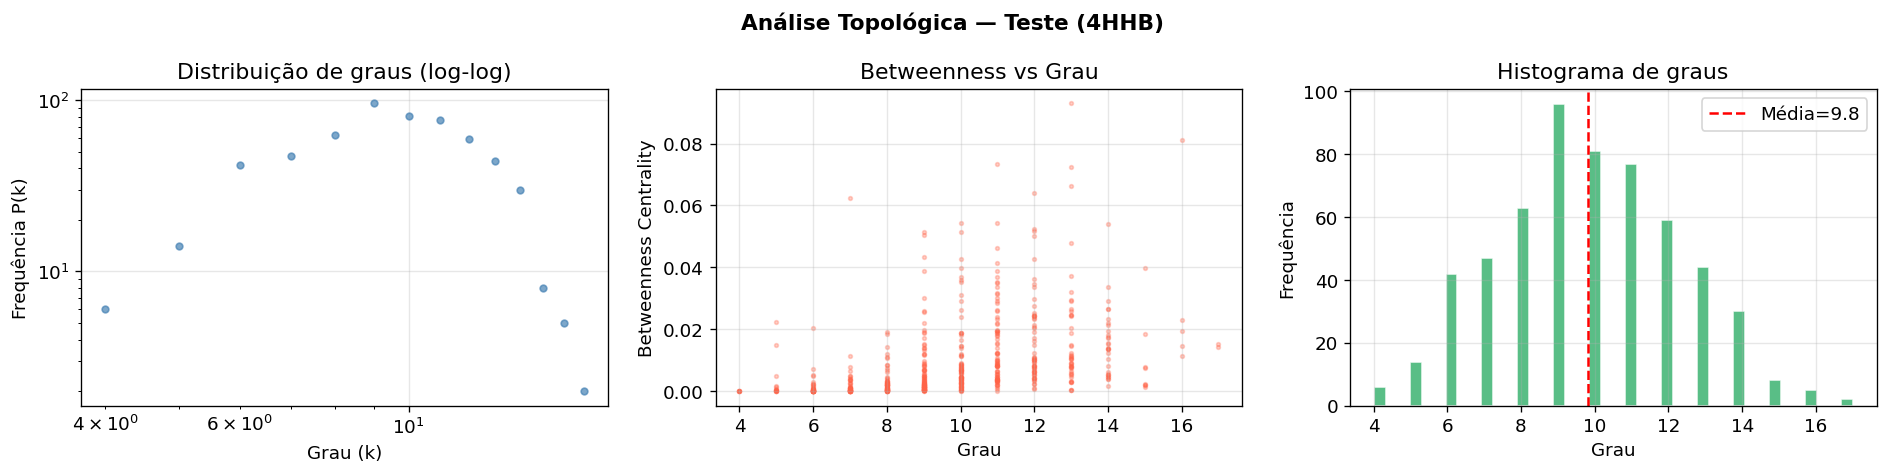

In [11]:
# Análise topológica
topo_test = topological_analysis(G_test, title=f"Teste ({TEST_ID})")

In [12]:
# Detecção de comunidades
partition_test = detect_communities_louvain(G_test, resolution=1.0)

Executando detecção de comunidades (Louvain)...

Comunidades detectadas : 16
Modularidade           : 0.8114
Maior comunidade       : 61 nós
Menor comunidade       : 17 nós
Tamanho médio          : 35.9 ± 13.7

Distribuição de tamanhos:
  Comunidade   0:     61 nós
  Comunidade   1:     55 nós
  Comunidade   2:     52 nós
  Comunidade   3:     50 nós
  Comunidade   4:     46 nós
  Comunidade   5:     44 nós
  Comunidade   6:     37 nós
  Comunidade   7:     32 nós
  Comunidade   8:     32 nós
  Comunidade   9:     32 nós
  Comunidade  10:     32 nós
  Comunidade  11:     29 nós
  Comunidade  12:     19 nós
  Comunidade  13:     18 nós
  Comunidade  14:     18 nós
  Comunidade  15:     17 nós


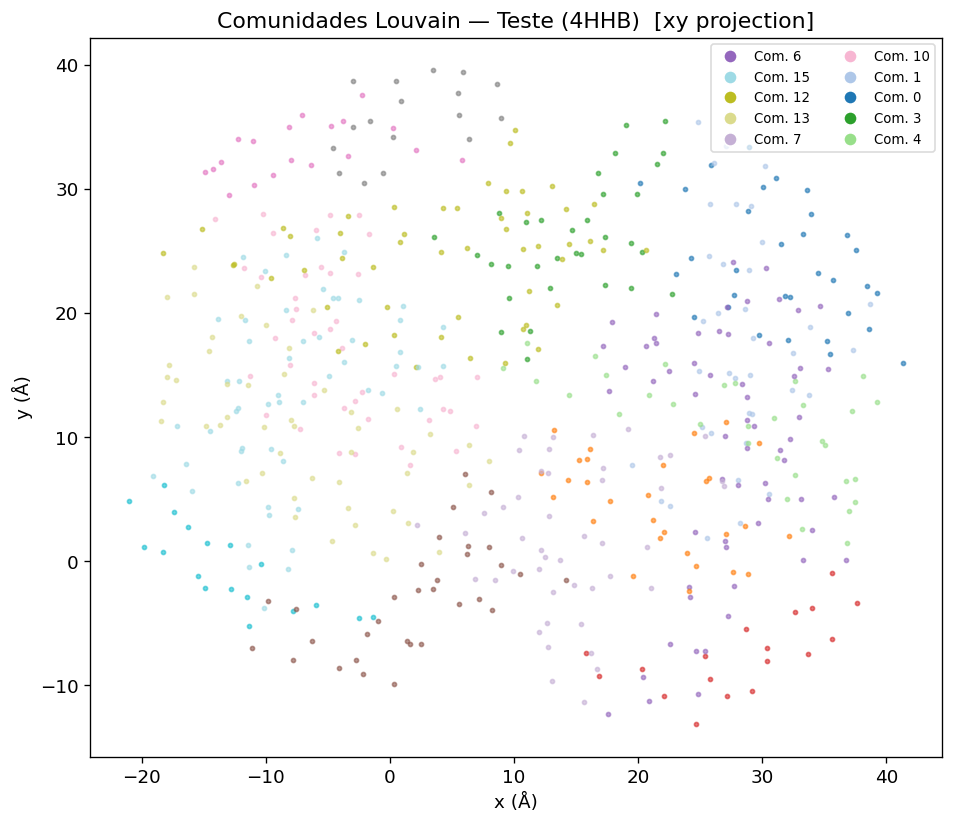

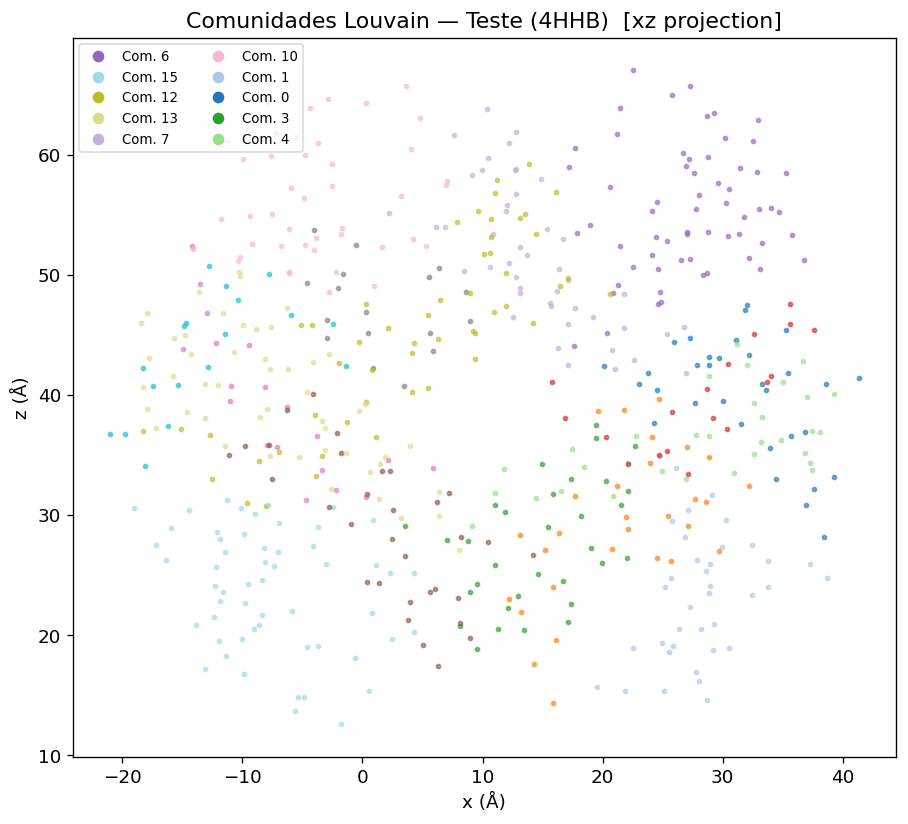

In [13]:
# Visualização 2D das comunidades
plot_communities_2d(G_test, partition_test, df_test, title=f"Teste ({TEST_ID})", projection="xy")
plot_communities_2d(G_test, partition_test, df_test, title=f"Teste ({TEST_ID})", projection="xz")


Pureza média das comunidades: 0.946
(1.0 = cada comunidade contém resíduos de apenas uma cadeia)

Resumo por comunidade (top-5):
 community   annotation  count
         0 alfa-globina     32
         1 alfa-globina     37
         2 alfa-globina     19
         2 beta-globina     10
         3 alfa-globina     32
         4 alfa-globina     21
         4 beta-globina     11
         5 beta-globina     18
         6 beta-globina     61
         7 beta-globina     46
         8 beta-globina     32
         9 alfa-globina     19
        10 alfa-globina     44
        11 alfa-globina     17
        12 alfa-globina     52
        13 beta-globina     41
        13 alfa-globina      9
        14 beta-globina     18
        15 beta-globina     55


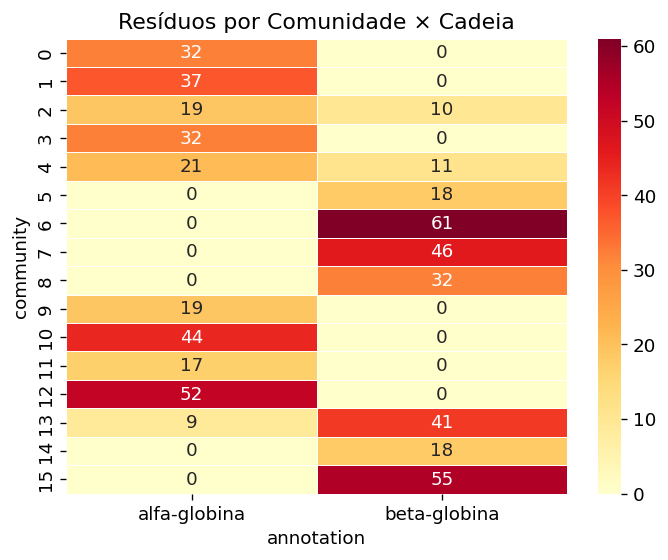

In [14]:
# Validação: para 4HHB, cadeias A/C = alfa-globina, B/D = beta-globina
chain_annotation_test = {
    "A": "alfa-globina",
    "B": "beta-globina",
    "C": "alfa-globina",
    "D": "beta-globina",
}

summary_test = validate_communities(partition_test, df_test, chain_annotation_test)

---
# ETAPA B — Proteína alvo: 6B1T (Adenovírus Humano 5)

> ⚠️ **Atenção:** 6B1T é enorme (~10 GB em memória).  
> Execute esta seção somente em uma máquina com ≥16 GB de RAM.  
> Se necessário, substitua `TARGET_ID` por uma proteína alternativa com ≥4 grupos funcionais.

In [15]:
# ── Configuração do alvo ──────────────────────────────────────

# Alvo principal:
TARGET_ID = "6B1T"

# Alternativas com ≥4 grupos funcionais:
#   "3J3Q" - Ribossomo bacteriano completo  (~5500 resíduos proteicos)
#   "1AON" - GroEL-GroES                   (~8500 resíduos, 21 cadeias)
#   "5GAN" - Vírus satélite do tabaco      (~1500 resíduos, 20+ cadeias)

CUTOFF_TARGET = 8.0  # Å
LOUVAIN_RESOLUTION = 1.0  # aumentar → mais comunidades menores

print(f"Alvo configurado: {TARGET_ID}")

Alvo configurado: 6B1T


In [16]:
# Download do alvo (pode demorar vários minutos)
target_file = download_pdb(TARGET_ID)

Download concluído: data\6B1T.cif.gz


In [17]:
# Parsing do alvo (pode consumir bastante RAM)
target_struct = parse_structure(target_file)

Estrutura '6B1T' carregada: 25 cadeias, 12544 resíduos.


In [18]:
# Extração dos resíduos
df_target = get_residue_info(target_struct)
print(f"Total de resíduos no alvo: {len(df_target)}")
print(f"Cadeias presentes: {sorted(df_target['chain'].unique())}")

Resíduos padrão (aminoácidos): 12544
Total de resíduos no alvo: 12544
Cadeias presentes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [19]:
# Construir rede do alvo
# NOTA: para 6B1T completo isso pode levar vários minutos e exigir muita RAM.
# Se ocorrer MemoryError, reduza chunk_size ou use uma proteína alternativa.
G_target = build_contact_network(df_target, cutoff=CUTOFF_TARGET, chunk_size=1000)

Calculando distâncias: 100%|██████████| 13/13 [00:00<00:00, 15.22it/s]


Grafo construído: 12544 nós, 66809 arestas.



 Análise topológica: Alvo (6B1T)
Nós: 12544  |  Arestas: 66809
Grau médio: 10.65 ± 2.77
Grau máximo: 20  |  Grau mínimo: 2
Calculando centralidade de grau...
Calculando closeness centrality...
Rede grande — betweenness amostrado (k=500)...
Calculando PageRank...

Top-10 resíduos por Betweenness Centrality:
  C_755            chain=C  ASN755  BC=0.07722
  C_758            chain=C  GLN758  BC=0.07664
  G_700            chain=G  THR700  BC=0.07014
  C_344            chain=C  ASN344  BC=0.06949
  K_700            chain=K  THR700  BC=0.06258
  E_920            chain=E  PHE920  BC=0.06226
  E_945            chain=E  PHE945  BC=0.06168
  C_923            chain=C  PHE923  BC=0.05731
  C_339            chain=C  TYR339  BC=0.05543
  K_697            chain=K  PRO697  BC=0.04753


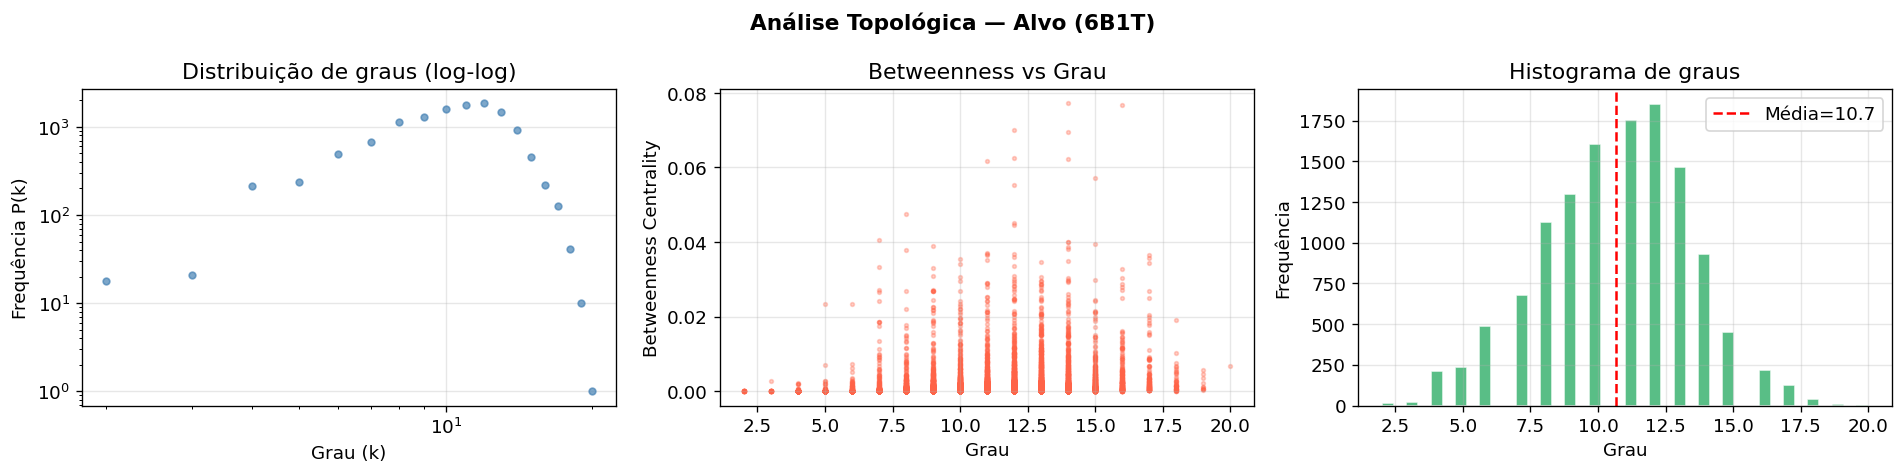

In [20]:
# Análise topológica do alvo
topo_target = topological_analysis(G_target, title=f"Alvo ({TARGET_ID})")

In [21]:
# Detecção de comunidades no alvo
partition_target = detect_communities_louvain(G_target, resolution=LOUVAIN_RESOLUTION)

Executando detecção de comunidades (Louvain)...

Comunidades detectadas : 37
Modularidade           : 0.9133
Maior comunidade       : 547 nós
Menor comunidade       : 47 nós
Tamanho médio          : 339.0 ± 115.0

Distribuição de tamanhos:
  Comunidade   0:    547 nós
  Comunidade   1:    510 nós
  Comunidade   2:    498 nós
  Comunidade   3:    496 nós
  Comunidade   4:    491 nós
  Comunidade   5:    491 nós
  Comunidade   6:    485 nós
  Comunidade   7:    458 nós
  Comunidade   8:    456 nós
  Comunidade   9:    426 nós
  Comunidade  10:    420 nós
  Comunidade  11:    410 nós
  Comunidade  12:    398 nós
  Comunidade  13:    360 nós
  Comunidade  14:    350 nós
  Comunidade  15:    346 nós
  Comunidade  16:    341 nós
  Comunidade  17:    336 nós
  Comunidade  18:    331 nós
  Comunidade  19:    317 nós
  ... (+17 menores)


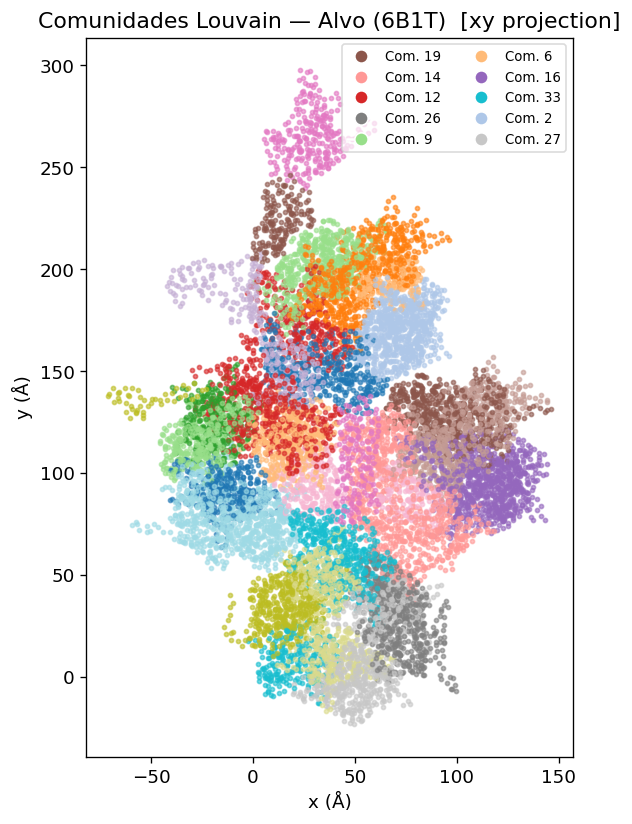

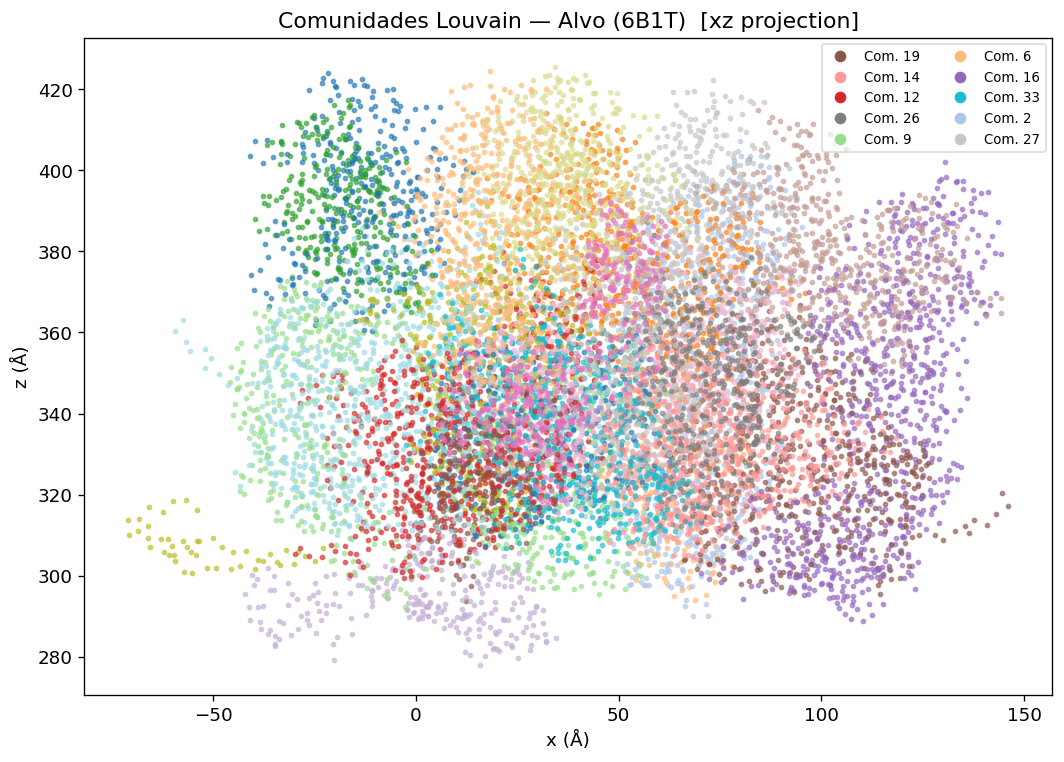

In [22]:
# Visualização 2D
plot_communities_2d(G_target, partition_target, df_target,
                   title=f"Alvo ({TARGET_ID})", projection="xy")
plot_communities_2d(G_target, partition_target, df_target,
                   title=f"Alvo ({TARGET_ID})", projection="xz")

In [23]:
# ── Anotações biológicas para 6B1T ────────────────────────────
# Fonte: https://www.rcsb.org/annotations/6B1T
# Estrutura do adenovírus: hexon (capsídeo externo) e penton base (vértices)
# As cadeias exatas dependem da versão do PDB — ajuste conforme necessário.

# Exemplo genérico (ajuste após inspecionar df_target['chain'].unique())
chain_annotation_target = {}

# Inspecione as cadeias disponíveis:
chain_counts = df_target.groupby("chain").size().sort_values(ascending=False)
print("Cadeias e número de resíduos:")
print(chain_counts.to_string())

Cadeias e número de resíduos:
chain
E    914
H    913
J    913
L    912
B    910
C    910
F    910
I    910
K    910
G    909
A    908
D    906
M    455
N    288
O    180
P    180
Q    119
R     93
T     88
S     86
X     33
U     29
V     29
Y     28
W     11



Pureza média das comunidades: 0.952
(1.0 = cada comunidade contém resíduos de apenas uma cadeia)

Resumo por comunidade (top-5):
 community   annotation  count
         0        hexon    346
         1        hexon    381
         1      unknown     14
         1 protein_VIII      3
         2        hexon    456
         3        hexon    299
         4        hexon    310
         5        hexon    331
         6        hexon    491
         7        hexon    188
         8        hexon    294
         9        hexon    475
         9      unknown     14
         9  penton_base      2
        10        hexon    304
        10 protein_IIIa     32
        11        hexon    308
        12        hexon    375
        12 protein_VIII    123
        13        hexon    261
        13      unknown     42
        14        hexon    485
        14      unknown     17
        14 protein_VIII      8
        15        hexon    298
        15      unknown     43
        16        hexon    485
  

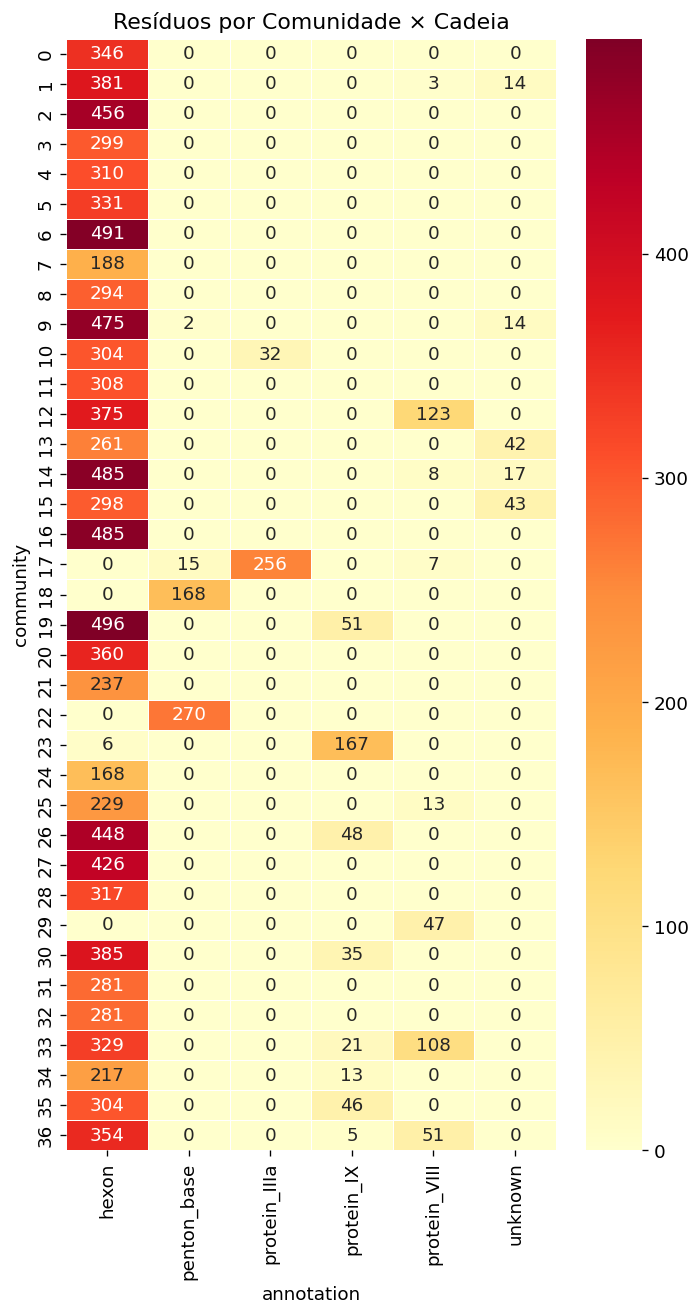

In [ ]:
# ── AJUSTE MANUAL as anotações após inspecionar a saída acima ──
# https://www.rcsb.org/annotations/6B1T para identificar cada cadeia.

chain_annotation_target = {
    "A": "hexon",
    "B": "hexon",
    "C": "hexon",
    "D": "hexon",
    "E": "hexon",
    "F": "hexon",
    "G": "hexon",
    "H": "hexon",
    "I": "hexon",
    "J": "hexon",
    "K": "hexon",
    "L": "hexon",

    "M": "penton_base",

    "N": "protein_IIIa",

    "O": "protein_VIII",
    "P": "protein_VIII",

    "Q": "protein_IX",
    "R": "protein_IX",
    "S": "protein_IX",
    "T": "protein_IX",

    "U": "unknown",
    "V": "unknown",
    "W": "unknown",
    "X": "unknown",
    "Y": "unknown",
}

# Por enquanto, usamos o id da cadeia como anotação:
# chain_annotation_target = None  # None → usa nome da cadeia diretamente

summary_target = validate_communities(partition_target, df_target, chain_annotation_target)

---
## 8. Comparação resumida: teste vs. alvo

In [29]:
import community as community_louvain

def summary_table(G, partition, name):
    deg = np.array([d for _, d in G.degree()])
    n_comm = len(set(partition.values()))
    mod = community_louvain.modularity(partition, G, weight="weight")
    return {
        "Proteína": name,
        "Nós": G.number_of_nodes(),
        "Arestas": G.number_of_edges(),
        "Grau médio": round(deg.mean(), 2),
        "Comunidades": n_comm,
        "Modularidade": round(mod, 4),
    }

rows = [summary_table(G_test, partition_test, f"Teste ({TEST_ID})")]

# Só adiciona alvo se já foi calculado
if 'G_target' in dir() and 'partition_target' in dir():
    rows.append(summary_table(G_target, partition_target, f"Alvo ({TARGET_ID})"))

pd.DataFrame(rows).set_index("Proteína")

,Nós,Arestas,Grau médio,Comunidades,Modularidade
Proteína,,,,,
Teste (4HHB),574,2817,9.82,16,0.8114
Alvo (6B1T),12544,66809,10.65,37,0.9133


---
## 9. Exportar resultados para o relatório

In [30]:
# Salvar partições em CSV
def save_partition(partition, df_res, filename):
    df_out = pd.DataFrame([
        {"node": n,
         "community": c,
         "chain": df_res.loc[n, "chain"] if n in df_res.index else "?",
         "resname": df_res.loc[n, "resname"] if n in df_res.index else "?",
         "resseq": df_res.loc[n, "resseq"] if n in df_res.index else -1}
        for n, c in partition.items()
    ])
    df_out.to_csv(filename, index=False)
    print(f"Salvo: {filename}")

save_partition(partition_test, df_test, DATA_DIR / f"partition_{TEST_ID}.csv")

if 'partition_target' in dir():
    save_partition(partition_target, df_target, DATA_DIR / f"partition_{TARGET_ID}.csv")

print("\nArquivos na pasta data/:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

Salvo: data\partition_4HHB.csv
Salvo: data\partition_6B1T.csv

Arquivos na pasta data/:
  4HHB.cif.gz  (183 KB)
  6B1T.cif.gz  (2159 KB)
  comunidades_Alvo_(6B1T)_xy.png  (324 KB)
  comunidades_Alvo_(6B1T)_xz.png  (562 KB)
  comunidades_Teste_(4HHB)_xy.png  (74 KB)
  comunidades_Teste_(4HHB)_xz.png  (72 KB)
  partition_4HHB.csv  (10 KB)
  partition_6B1T.csv  (237 KB)
  topologia_Alvo_(6B1T).png  (88 KB)
  topologia_Teste_(4HHB).png  (78 KB)
  validacao_heatmap.png  (116 KB)


---
## 10. Visualização 3D inline (opcional — requer py3Dmol)

In [27]:
# Visualização 3D da proteína de teste colorida por comunidade
# (funciona em Jupyter Notebook clássico; pode não renderizar em JupyterLab sem extensão)
try:
    view_3d_communities(TEST_ID, partition_test, df_test)
except Exception as e:
    print(f"Visualização 3D indisponível: {e}")
    print("Para visualização 3D interativa, acesse: https://www.rcsb.org/3d-view/" + TEST_ID)

Visualização 3D indisponível: [Errno 2] No such file or directory: 'data\\4HHB.pdb.gz'
Para visualização 3D interativa, acesse: https://www.rcsb.org/3d-view/4HHB
